In [7]:
import cmath
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pylab import *
import warnings
warnings.filterwarnings("ignore")

In [8]:
class R2:
    def __init__(self):
        pass
    def edis(x,y):
        x1 = np.array([x.real,x.imag])
        y1 = np.array([y.real,y.imag])
        return(np.sqrt(np.sum(np.square(x1 - y1))))
    def plane(a,b,c,d):
        xmesh = np.linspace(a,b,1000,endpoint=True)
        ymesh = np.linspace(c,d,1000,endpoint=True)
        plane = []
        for i in xmesh:
            for j in ymesh:
                plane.append(complex(i,j))
        return(plane)
    def ball(a,r):
        searchspace = R2.plane(-10,10,-10,10)
        points = []
        for i in searchspace:
            if R2.edis(a,i)<r:
                points.append(i)
        return(points)
    def line(a,b,c):
        if c!=0 and b!=0:
            xlim = max(b/c,10)
            xvals = np.linspace(-xlim,xlim,1000,endpoint=True)
            yvals = [(c-a*i)/b for i in xvals]
            points = [complex(xvals[i],yvals[i]) for i in range(len(xvals))]
            return(points)
        elif c==0 and b!=0:
            xvals=np.linspace(-10,10,1000,endpoint=True)
            yvals = [(c-a*i)/b for i in xvals]
            points = [complex(xvals[i],yvals[i]) for i in range(len(xvals))]
            return(points)
        elif c==0 and b==0:
            yvals=np.linspace(-10,10,1000,endpoint=True)
            points = [complex(0,i) for i in yvals]
            return(points)
        elif c!=0 and b==0:
            yvals=np.linspace(-10,10,1000,endpoint=True)
            points = [complex(c,i) for i in yvals]
            return(points)
    def mesh(n):
        points = []
        for i in range(n+1):
            points = points + R2.line(0,1,i) + R2.line(1,0,i) + R2.line(0,1,-i) + R2.line(1,0,-i)
        return(points)
    def uhalf():
        searchspace = R2.plane(-10,10,-10,10)
        points = []
        for i in searchspace:
            if i.imag>0:
                points.append(i)
        return(points)
    def annulus(a,r1,r2):
        searchspace = R2.plane(-10,10,-10,10)
        points = []
        for i in searchspace:
            if edis(a,i)>r1 and edis(a,i)<r2:
                points.append(i)
        return(points)
    def circ(a,r):
        theta = np.linspace(0,2*np.pi,1000,endpoint=False)
        xvals = [r*np.cos(i)+a.real for i in theta]
        yvals = [r*np.sin(i)+a.imag for i in theta]
        points = [complex(xvals[i],yvals[i]) for i in range(len(xvals))]
        return(points)
    def sector(alpha):
        searchspace = R2.plane(-10,10,-10,10)
        points = []
        for i in searchspace:
            if cmath.phase(i)>0 and abs(cmath.phase(i))<alpha:
                points.append(i)
        return(points)

In [9]:
def plot(arr,function):
    def f(z):
        return(eval(function))
    xvals = [i.real for i in arr]
    yvals = [i.imag for i in arr]
    images = [f(i) for i in arr]
    ximvals = [i.real for i in images]
    yimvals = [i.imag for i in images]
    lim1 = max(xvals+yvals)
    lim2 = max(ximvals+yimvals)
    figure()
    ax1 = subplot(121, autoscale_on=False, aspect='equal', xlim=[-lim1,lim1], ylim=[-lim1,lim1])
    ax2 = subplot(122, autoscale_on=False, aspect='equal', xlim=[-lim2,lim2], ylim=[-lim2,lim2])
    return(ax1.scatter(xvals, yvals, s=1), ax2.scatter(ximvals, yimvals, s=1))

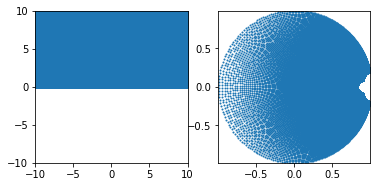

In [10]:
j = complex(0,1)
plot(R2.uhalf(),'(z-j)/(z+j)');